# Holodeck / ProcTHOR Interactive Viewer

加载一个 ProcTHOR JSON 场景，启动 AI2-THOR，查看主视角与俯视图，并通过按钮进行基本交互（移动/转向/抬头/低头/传送到起始点等）。

提示：
- 若看不到按钮，请先安装 ipywidgets：`pip install ipywidgets` 并启用 Jupyter 扩展。
- 默认分辨率使用 640x480 以避免某些环境下的分辨率降级错误。


In [1]:
import os, sys, copy
import compress_json as cj
from PIL import Image
from IPython.display import display, clear_output

# 确保可以 import ai2holodeck.*
sys.path.append(os.path.abspath('Holodeck'))

import ai2thor
from ai2thor.controller import Controller
from ai2thor.hooks.procedural_asset_hook import ProceduralAssetHookRunner

from holodeck_langgraph.config.constants import THOR_COMMIT_ID, OBJATHOR_ASSETS_DIR, HOLODECK_BASE_DATA_DIR

# 交互控件（按钮）
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

controller = None
scene = None


ModuleNotFoundError: No module named 'holodeck_langgraph'

In [42]:
# 选择并加载 JSON 场景
SCENE_JSON = os.path.join('scenedata/floor5.json')
# 如需加载你的生成结果，请改成类似：
# SCENE_JSON = 'Holodeck/data/scenes/<your-scene-folder>/a_cozy_living_room.json'

print('Scene JSON:', SCENE_JSON)
scene = cj.load(SCENE_JSON)
print('Loaded scene: rooms=', len(scene.get('rooms', [])), 'objects=', len(scene.get('objects', [])))


Scene JSON: scenedata/floor5.json
Loaded scene: rooms= 9 objects= 231


In [ ]:
# 启动 Controller（参考 Holodeck/connect_to_unity.py）
def start_controller(width=640, height=480, port=8200):
    global controller
    if controller is not None:
        try:
            controller.stop()
        except Exception:
            pass
    controller = Controller(
        # commit_id=THOR_COMMIT_ID,
        local_executable_path= "/home/agiuser/.ai2thor/releases/thor-Linux64-local/thor-Linux64-local/thor-Linux64-local",
        start_unity=True,
        scene='Procedural',
        gridSize=0.2,
        width=width,
        height=height,
        server_class=ai2thor.wsgi_server.WsgiServer,
        makeAgentsVisible=True,
        visibilityScheme='Distance',
        action_hook_runner=ProceduralAssetHookRunner(
            asset_directory=OBJATHOR_ASSETS_DIR, asset_symlink=True, verbose=True
        ),
    )
    controller.step(action='CreateHouse', house=scene, raise_for_failure=True)
    controller.step(action='Pass', raise_for_failure=True)
    print('Controller started and house created.')

start_controller()
Image.fromarray(controller.last_event.frame)


In [1]:
# 选择并加载 JSON 场景
SCENE_JSON = os.path.join('scenedata/floor1.json')
# 如需加载你的生成结果，请改成类似：
# SCENE_JSON = 'Holodeck/data/scenes/<your-scene-folder>/a_cozy_living_room.json'

print('Scene JSON:', SCENE_JSON)
scene = cj.load(SCENE_JSON)
print('Loaded scene: rooms=', len(scene.get('rooms', [])), 'objects=', len(scene.get('objects', [])))
scene = set_exterior_walls_material(scene, 'Glass1')


start_controller()
Image.fromarray(controller.last_event.frame)


# 辅助函数：显示等轴测视图（Isometric View）
def show_isometric_view(rotation_y=45, tilt_angle=30, height_multiplier=1.5, height_offset=2.7, height_multiplier_offset=1.0):
    """
    生成等轴测视图（类似图片中的 3D 视角）

    参数:
        rotation_y: 相机围绕 Y 轴的旋转角度（0-360），45度是经典的等轴测视角
        tilt_angle: 相机向下倾斜的角度（0-90），30-45度比较合适
        height_multiplier: 相机高度倍数，越大视角越高
    """
    # 获取场景边界和地图视图相机属性
    event = controller.step(action='GetMapViewCameraProperties', raise_for_failure=True)
    pose = copy.deepcopy(event.metadata['actionReturn'])
    bounds = event.metadata['sceneBounds']['size']

    # 计算场景中心点
    center_x = event.metadata['sceneBounds']['center']['x']
    center_z = event.metadata['sceneBounds']['center']['z']
    max_bound = max(bounds['x'], bounds['z'])

    # 设置相机位置（在场景中心上方）
    pose['position']['x'] = center_x -60
    pose['position']['z'] = center_z -160
    pose['position']['y'] = max_bound * height_multiplier + height_offset * height_multiplier_offset

    # 设置相机旋转（等轴测视角）
    # x: 向下倾斜角度（tilt_angle）
    # y: 围绕场景旋转角度（rotation_y）
    # z: 0（不倾斜）
    pose['rotation'] = {
        'x': tilt_angle,  # 向下倾斜 30-45 度
        'y': rotation_y,  # 围绕 Y 轴旋转（45度是经典等轴测视角）
        'z': 0
    }

    # 设置视野参数
    pose['fieldOfView'] = 120 # 视野角度
    pose['orthographic'] = True  # 使用透视投影（等轴测视图）
    pose['orthographicSize'] = 8 # 透视投影大小
    pose['farClippingPlane'] = 500  # 远裁剪平面

    # 移除不需要的参数
    # pose.pop('orthographicSize', None)

    # 添加第三方相机
    controller.step(
        action='AddThirdPartyCamera', 
        skyboxColor='white', 
        raise_for_failure=True, 
        **pose
    )

    # 渲染一帧
    ev = controller.step(action='Pass', raise_for_failure=True)

    # 获取相机帧
    frame = ev.third_party_camera_frames[-1] if getattr(ev, 'third_party_camera_frames', None) else ev.frame
    display(Image.fromarray(frame))

    return Image.fromarray(frame)




# 显示等轴测视图（默认 45 度视角，30 度倾斜）
image = show_isometric_view(rotation_y=20, tilt_angle=11, height_multiplier=0.1, height_offset=2.7, height_multiplier_offset=12)

# convert to RGBA
image = image.convert("RGBA")
data = image.getdata()
new_data = []
for item in data:
    if item[0] == 255 and item[1] == 255 and item[2] == 255:
        new_data.append((255, 255, 255, 0))
    else:
        new_data.append(item)
image.putdata(new_data)
# save to same directory of SCENE_JSON, with the same name of the scene json
save_path = os.path.join(os.path.dirname(SCENE_JSON), os.path.basename(SCENE_JSON).replace('.json', '_orth.png'))
image.save(save_path)
display(image)

stop_controller()

NameError: name 'os' is not defined

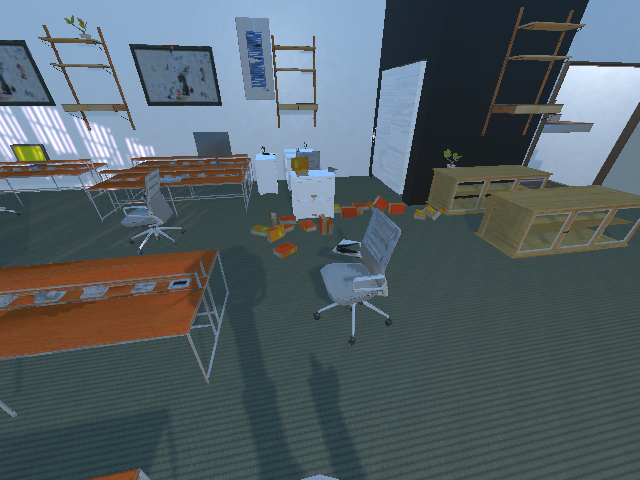

In [35]:
event = controller.step(action="MoveAhead")
Image.fromarray(event.frame)

In [ ]:
event = controller.step(action="CloseObject", objectId="door|3|upstairs_landing|bedroom_3")
Image.fromarray(event.frame)

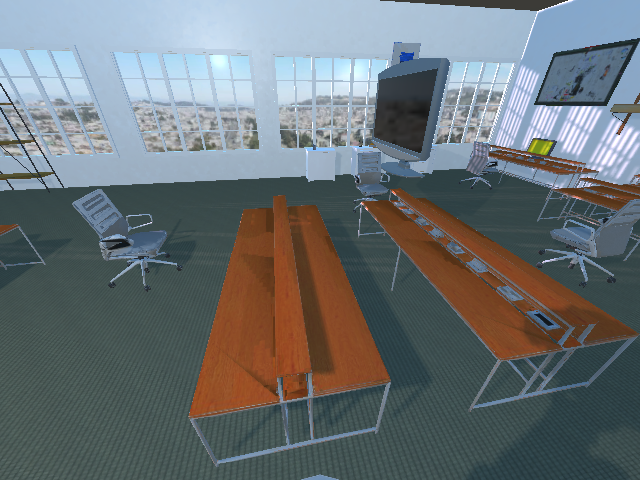

In [40]:
event = controller.step(action="RotateLeft", degrees=90)
Image.fromarray(event.frame)

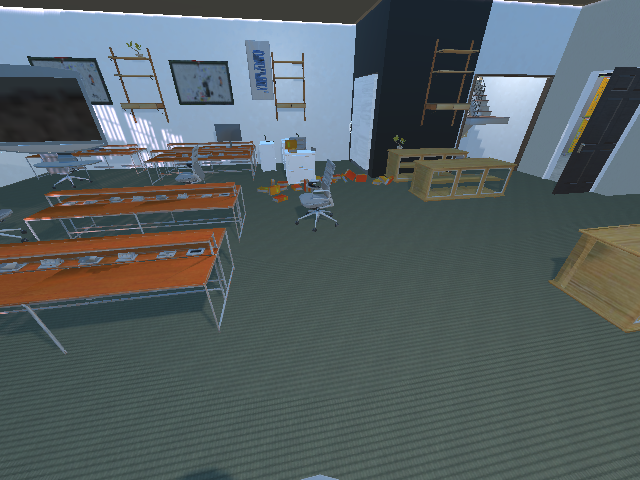

In [26]:
event = controller.step(action="RotateRight", degrees=50)
Image.fromarray(event.frame)

In [11]:

positions = controller.step(
    action="GetReachablePositions"
).metadata["actionReturn"]
print(positions)

[{'x': 2.0, 'y': 0.9009998, 'z': 18.5}, {'x': 2.2, 'y': 0.9009998, 'z': 18.5}, {'x': 2.0, 'y': 0.9009998, 'z': 18.7}, {'x': 1.8, 'y': 0.9009998, 'z': 18.5}, {'x': 2.0, 'y': 0.9009998, 'z': 18.3}, {'x': 2.4, 'y': 0.9009998, 'z': 18.5}, {'x': 2.2, 'y': 0.9009998, 'z': 18.7}, {'x': 2.2, 'y': 0.9009998, 'z': 18.3}, {'x': 2.0, 'y': 0.9009998, 'z': 18.9}, {'x': 1.8, 'y': 0.9009998, 'z': 18.7}, {'x': 1.6, 'y': 0.9009998, 'z': 18.5}, {'x': 1.8, 'y': 0.9009998, 'z': 18.3}, {'x': 2.0, 'y': 0.9009998, 'z': 18.1}, {'x': 2.6, 'y': 0.9009998, 'z': 18.5}, {'x': 2.4, 'y': 0.9009998, 'z': 18.7}, {'x': 2.4, 'y': 0.9009998, 'z': 18.3}, {'x': 2.2, 'y': 0.9009998, 'z': 18.9}, {'x': 2.2, 'y': 0.9009998, 'z': 18.1}, {'x': 2.0, 'y': 0.9009998, 'z': 19.1}, {'x': 1.8, 'y': 0.9009998, 'z': 18.9}, {'x': 1.6, 'y': 0.9009998, 'z': 18.7}, {'x': 1.4, 'y': 0.9009998, 'z': 18.5}, {'x': 1.6, 'y': 0.9009998, 'z': 18.3}, {'x': 1.8, 'y': 0.9009998, 'z': 18.1}, {'x': 2.0, 'y': 0.9009998, 'z': 17.9}, {'x': 2.8, 'y': 0.900999

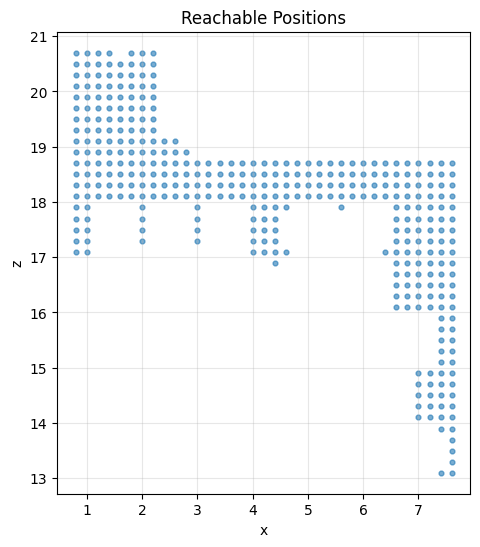

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 2D 俯视散点图（x-z 平面）
df = pd.DataFrame(positions)
plt.figure(figsize=(6, 6))
plt.scatter(df['x'], df['z'], s=12, alpha=0.6, color='tab:blue')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Reachable Positions')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, alpha=0.3)
plt.show()


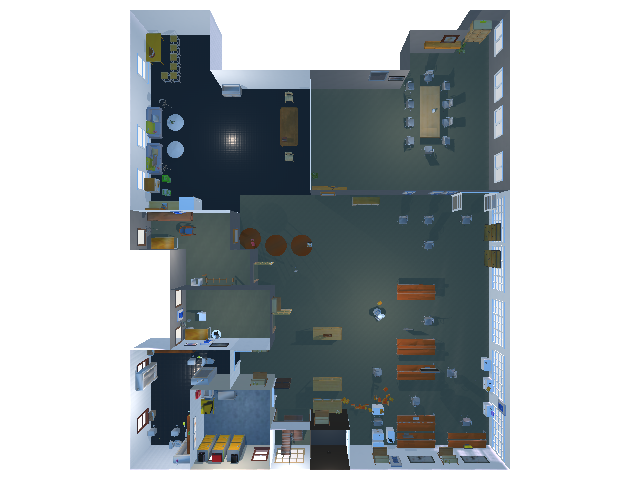

In [20]:
# 辅助函数：显示俯视图
def show_top_down():
    event = controller.step(action='GetMapViewCameraProperties', raise_for_failure=True)
    pose = copy.deepcopy(event.metadata['actionReturn'])
    bounds = event.metadata['sceneBounds']['size']
    max_bound = max(bounds['x'], bounds['z'])
    pose['fieldOfView'] = 50
    pose['position']['y'] += 1.1 * max_bound
    pose['orthographic'] = False
    pose['farClippingPlane'] = 50
    pose.pop('orthographicSize', None)
    controller.step(action='AddThirdPartyCamera', skyboxColor='white', raise_for_failure=True, **pose)
    ev = controller.step(action='Pass', raise_for_failure=True)
    frame = ev.third_party_camera_frames[-1] if getattr(ev, 'third_party_camera_frames', None) else ev.frame
    display(Image.fromarray(frame))

# 传送到 JSON 提供的 agent 起始位姿（若存在）
def teleport_to_spawn():
    agent = scene.get('metadata', {}).get('agent', None)
    if not agent:
        print('No metadata.agent found in scene.')
        return
    controller.step(
        action='TeleportFull',
        position=agent['position'],
        rotation=agent['rotation'],
        horizon=agent.get('horizon', 0),
        standing=agent.get('standing', True),
        forceAction=True,
        raise_for_failure=True,
    )
    controller.step(action='Pass', raise_for_failure=True)
    display(Image.fromarray(controller.last_event.frame))


show_top_down()

In [ ]:
# 本地替代：不依赖 google.colab.data_table
import pandas as pd
from IPython.display import display

# 设置pandas显示选项，显示所有行和列（避免表格被压缩）
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

def show_objects_table_local(objects, extra_cols=None, max_rows=2000):
    """
    objects: controller.last_event.metadata['objects']
    extra_cols: 额外需要显示的字段名列表
    """
    base_cols = [
        "objectId", "objectType", "visible",
        "openable", "toggleable", "pickupable",
    ]
    if extra_cols:
        cols = base_cols + list(extra_cols)
    else:
        cols = base_cols

    rows = []
    for o in objects[:max_rows]:
        row = {k: o.get(k) for k in cols}
        # 展开位置/朝向
        if isinstance(o.get("position"), dict):
            row.update({
                "x": o["position"].get("x"),
                "y": o["position"].get("y"),
                "z": o["position"].get("z"),
            })
        if isinstance(o.get("rotation"), dict):
            row.update({
                "rx": o["rotation"].get("x"),
                "ry": o["rotation"].get("y"),
                "rz": o["rotation"].get("z"),
            })
        rows.append(row)

    df = pd.DataFrame(rows)
    # 让关键信息更靠前
    front = [c for c in ["objectType","objectId","visible","openable","toggleable","pickupable","x","y","z","ry"] if c in df.columns]
    rest = [c for c in df.columns if c not in front]
    df = df[front + rest]
    display(df)
    return df

# 用法：
objs = controller.last_event.metadata["objects"]
_ = show_objects_table_local(objs)



In [ ]:
# 结束并清理
def stop_controller():
    global controller
    if controller is not None:
        try:
            controller.stop()
            print('Controller stopped.')
        finally:
            controller = None

# 调用示例：
# stop_controller()


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point

def compute_reachability(room_poly, obstacles, step=0.25, neighbor8=True):
    """栅格化平面，返回可达/不可达的空点集合"""
    minx, miny, maxx, maxy = room_poly.bounds
    pts = []
    for x in np.arange(minx, maxx, step):
        for y in np.arange(miny, maxy, step):
            p = Point(x, y)
            if not room_poly.covers(p):
                continue
            if any(obs.covers(p) for obs in obstacles):
                continue
            pts.append((round(x, 3), round(y, 3)))
    if not pts:
        return set(), set(), []

    pts_set = set(pts)
    start = next(iter(pts_set))  # 任意空点作为起点
    reachable = {start}
    stack = [start]
    dirs = [(step, 0), (-step, 0), (0, step), (0, -step)]
    if neighbor8:
        dirs += [(step, step), (step, -step), (-step, step), (-step, -step)]

    while stack:
        cx, cy = stack.pop()
        for dx, dy in dirs:
            nb = (round(cx + dx, 3), round(cy + dy, 3))
            if nb in pts_set and nb not in reachable:
                reachable.add(nb)
                stack.append(nb)

    unreachable = pts_set - reachable
    return reachable, unreachable, pts


def plot_reachability(room_poly, obstacles, reachable, unreachable):
    rx, ry = room_poly.exterior.xy
    plt.figure(figsize=(6, 6))
    plt.plot(rx, ry, 'k-', lw=1)
    for obs in obstacles:
        ox, oy = obs.exterior.xy
        plt.fill(ox, oy, color='gray', alpha=0.4)
    if unreachable:
        ux, uy = zip(*unreachable)
        plt.scatter(ux, uy, s=8, c='red', alpha=0.6, label='unreachable free')
    if reachable:
        px, py = zip(*reachable)
        plt.scatter(px, py, s=8, c='tab:blue', alpha=0.6, label='reachable')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# 使用示例（需构造 room_poly: Polygon，obstacles: [Polygon]）
# reachable, unreachable, _ = compute_reachability(room_poly, obstacles, step=0.25)
# plot_reachability(room_poly, obstacles, reachable, unreachable)
